# Lab 4 — Support Vector Machine (Iris)

Petal length + petal width. Linear / Polynomial / RBF kernels, then the effect of C and gamma.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

RS = 1370
TEST_SIZE = 0.30


## 1. Load (petal length + petal width)

In [2]:
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
FEATURES = ["petal length (cm)", "petal width (cm)"]
X = data[FEATURES].to_numpy()
y = iris.target
CLASS_NAMES = iris.target_names
print("X:", X.shape, "classes:", np.unique(y), "| missing:", data.isna().sum().sum())


X: (150, 2) classes: [0 1 2] | missing: 0


## 2. Split + scale

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RS, stratify=y)
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
print("Train:", len(X_train_s), "Test:", len(X_test_s))


Train: 105 Test: 45


## 3. Decision-boundary helper

In [4]:
def plot_boundary(model, title):
    low = X_train_s.min(0) - 0.6
    high = X_train_s.max(0) + 0.6
    xx, yy = np.meshgrid(np.linspace(low[0], high[0], 150),
                         np.linspace(low[1], high[1], 150))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    labels = model.predict(grid).reshape(xx.shape)
    plt.contourf(xx, yy, labels, levels=[-0.5, 0.5, 1.5, 2.5], cmap="coolwarm", alpha=0.3)
    plt.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap="coolwarm")
    sv = model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors="none", edgecolors="k")
    plt.xlabel("Scaled petal length")
    plt.ylabel("Scaled petal width")
    plt.title(title)
    plt.show()


## 4. Three kernels

linear support vectors: 24 per class: [ 2 12 10]
Support indices: [ 19  54   7   8  10  18  22  23  31  68  81  85  86  98  14  16  49  61
  65  78  79  89 100 104]
Train/test: 0.9619047619047619 0.9333333333333333


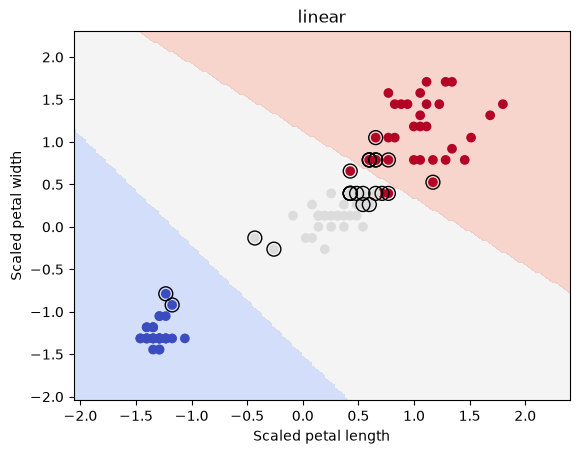

poly support vectors: 26 per class: [ 2 13 11]
Support indices: [ 19  54   7   8  10  18  22  23  31  51  68  81  85  86  98  14  16  44
  49  61  65  78  79  89 100 104]
Train/test: 0.9333333333333333 0.9777777777777777


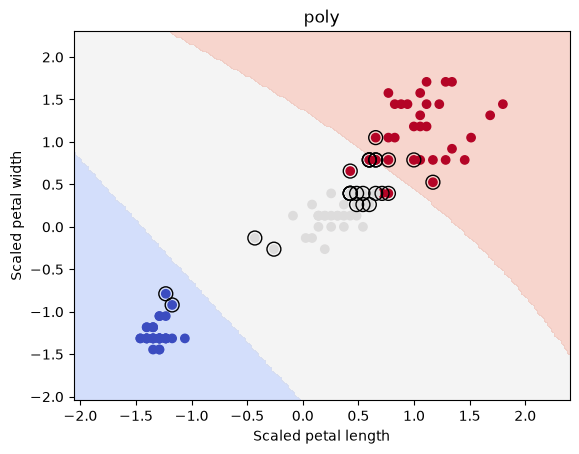

rbf support vectors: 30 per class: [ 4 12 14]
Support indices: [ 19  39  46  54   7   8  10  18  22  23  31  68  81  85  86  98   6   9
  14  16  29  44  49  61  65  78  79  89 100 104]
Train/test: 0.9619047619047619 0.9333333333333333


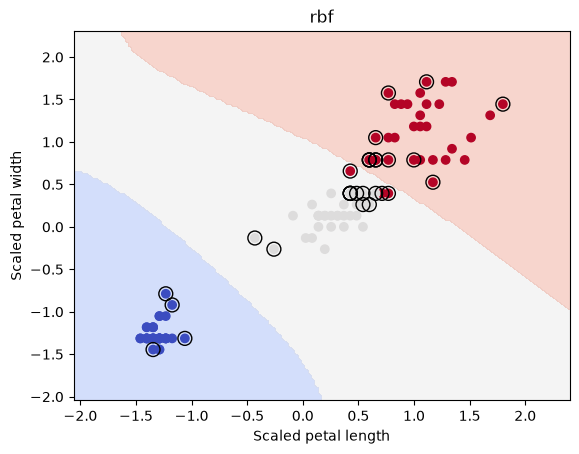

In [5]:
results = {}
for kernel in ["linear", "poly", "rbf"]:
    model = SVC(kernel=kernel, C=1, degree=3, gamma="scale")
    model.fit(X_train_s, y_train)
    results[kernel] = model
    print(kernel, "support vectors:", len(model.support_), "per class:", model.n_support_)
    print("Support indices:", model.support_)
    print("Train/test:", model.score(X_train_s, y_train), model.score(X_test_s, y_test))
    plot_boundary(model, kernel)


## 5. Kernel comparison table

In [6]:
comp = pd.DataFrame([{"Kernel":k, "Support vectors":len(m.support_),
                     "Test accuracy":accuracy_score(y_test, m.predict(X_test_s))}
                    for k,m in results.items()])
print(comp.round(4).to_string(index=False))


Kernel  Support vectors  Test accuracy
linear               24         0.9333
  poly               26         0.9778
   rbf               30         0.9333


## 6. Effect of C

In [7]:
for C in [0.01, 0.1, 1, 10, 100]:
    for kernel in ["linear", "poly", "rbf"]:
        model = SVC(kernel=kernel, C=C, degree=3, gamma="scale").fit(X_train_s, y_train)
        print(C, kernel, "SV/train/test:", len(model.support_),
              model.score(X_train_s, y_train), model.score(X_test_s, y_test))


0.01 linear SV/train/test: 104 0.9619047619047619 0.9555555555555556
0.01 poly SV/train/test: 104 0.7238095238095238 0.7333333333333333
0.01 rbf SV/train/test: 105 0.9619047619047619 0.9555555555555556
0.1 linear SV/train/test: 56 0.9619047619047619 0.9555555555555556
0.1 poly SV/train/test: 56 0.8952380952380953 0.8444444444444444
0.1 rbf SV/train/test: 83 0.9619047619047619 0.9555555555555556
1 linear SV/train/test: 24 0.9619047619047619 0.9333333333333333


1 poly SV/train/test: 26 0.9333333333333333 0.9777777777777777
1 rbf SV/train/test: 30 0.9619047619047619 0.9333333333333333
10 linear SV/train/test: 12 0.9714285714285714 0.9555555555555556
10 poly SV/train/test: 14 0.9619047619047619 0.9555555555555556
10 rbf SV/train/test: 17 0.9714285714285714 0.9555555555555556
100 linear SV/train/test: 10 0.9714285714285714 0.9333333333333333
100 poly SV/train/test: 10 0.9809523809523809 0.9555555555555556
100 rbf SV/train/test: 14 0.9714285714285714 0.9333333333333333


## 7. Effect of gamma (RBF)

In [8]:
for gamma in [0.01, 0.1, 1, 10, 100]:
    model = SVC(kernel="rbf", C=1, gamma=gamma).fit(X_train_s, y_train)
    print(gamma, "SV/train/test:", len(model.support_),
          model.score(X_train_s, y_train), model.score(X_test_s, y_test))


0.01 SV/train/test: 93 0.9619047619047619 0.9555555555555556
0.1 SV/train/test: 44 0.9619047619047619 0.9555555555555556
1 SV/train/test: 27 0.9619047619047619 0.9555555555555556
10 SV/train/test: 36 0.9904761904761905 0.9555555555555556
100 SV/train/test: 72 0.9904761904761905 0.7777777777777778


## 8. Highest test accuracy on this split

This matches the lab comparison at C=1. Repeated test-set comparisons are
exploratory. Use validation/CV to tune a model before a final test evaluation.

In [9]:
best = comp.loc[comp["Test accuracy"].idxmax()]
print("Best kernel:", best["Kernel"], "| test accuracy:", round(best["Test accuracy"],4))


Best kernel: poly | test accuracy: 0.9778
